In [1]:
%matplotlib inline

import numpy as np
import pylab as plt
import os
import healpy as hp

Global Sky Model 2016
----------------------

Zheng et al. released an updated sky model here: https://github.com/jeffzhen/gsm2016. In McKay et al., the authors propose a correction to the GSM16 valid across 60-350 MHz. 


This notebook is the documentation for the PyGDSM port, for the `GlobalSkyModel16` class.
 The GSM16 with low-frequency correction is available via the `McKaySkyModel` class.

#### An Improved Model of Diffuse Galactic Radio Emission from 10 MHz to 5 THz
###### H. Zheng (MIT), M. Tegmark, J. Dillon, A. Liu, A. Neben, J. Jonas, P. Reich, W.Reich
[MNRAS, 464, 3, 3486-3497 (2017)](https://ui.adsabs.harvard.edu/abs/2017MNRAS.464.3486Z/abstract)




#### Precise Measurement of the Absolute Sky Brightness at 60 to 350 MHz
###### Luke McKay, Ravi Subrahmanyan, Aaron Chippendale, Pietro Bolli, Georgios Kyriakou, Alex Dunning, Ronald Ekers
[arXiv:2509.11846](https://arxiv.org/abs/2509.11846)



### Import modules
Firstly, we import the `pygdsm` module:

In [2]:
from pygdsm import GlobalSkyModel16
from pygdsm import GlobalSkyModel

We can very quickly get started with generating a sky map and plotting it:

/Users/daniel.price/Data/pygdsm/pygdsm/base_skymodel.py:98: RuntimeWarning: invalid value encountered in log2
  gmap = np.log2(gmap)


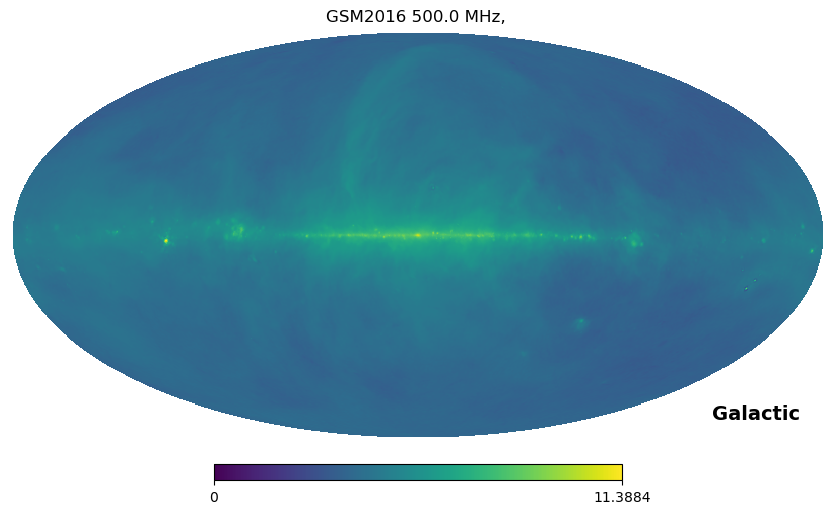

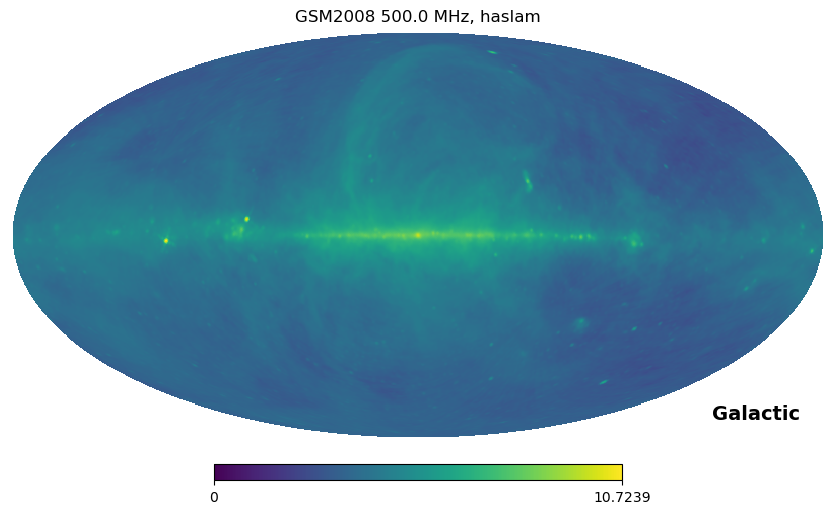

In [3]:
gsm_2016 = GlobalSkyModel16(freq_unit='MHz')
gsm_2016.generate(500)
gsm_2016.view(logged=True)

# Compare to 2008 De-Olivera Costa version
gsm_2008 = GlobalSkyModel(freq_unit='MHz')
gsm_2008.generate(500)
gsm_2008.view(logged=True)

We might then want to write this to a FITS file (in healpix format):

In [4]:
if not os.path.exists("gdsm16_500mhz.fits"):
    gsm_2016.write_fits("gdsm16_500mhz.fits")

There are also a few options we can play around with. For example:

* let's change to use a different interpolation method (pchip) 
* instead of using the Haslam 408 MHz map for structure, let's use WMAP 23 GHz
* instead of using MHz to define the units, let's use GHz

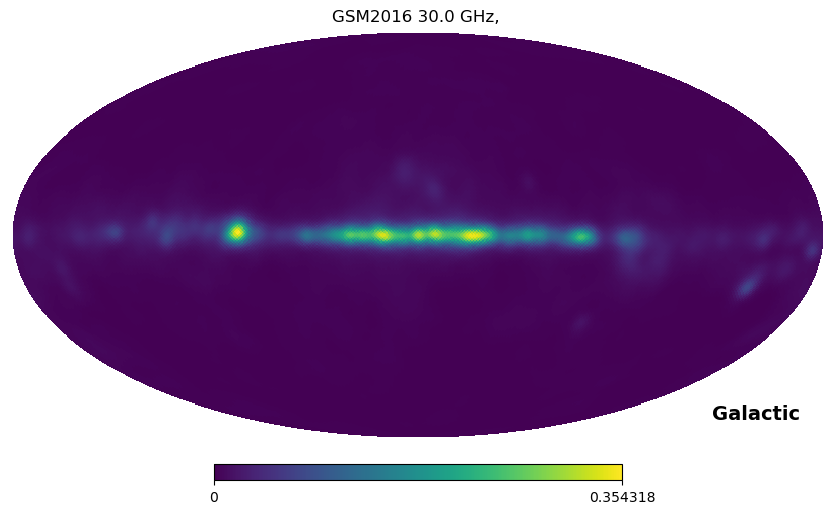

In [5]:
gsm = GlobalSkyModel16(freq_unit='GHz', data_unit='MJysr', resolution='low')
gsm.generate(30) # Generate at 30 GHz
gsm.view(logged=False)

You can set things on the fly, too, once you've got a `gsm` object:

Just in case you're interested in spectral cubes, you can even pass a frequency range:

(10, 12582912)


Text(0, 0.5, 'Temperature [K]')

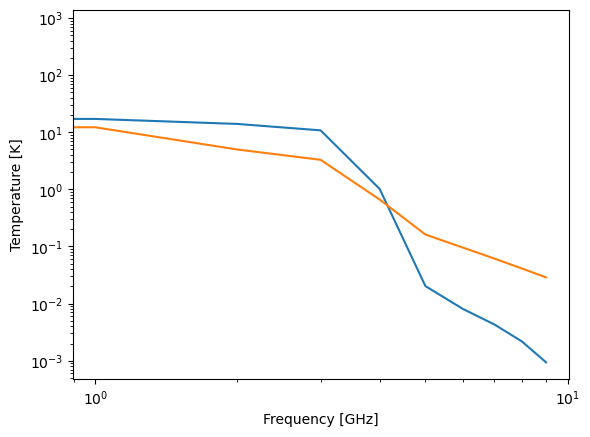

In [6]:
gsm = GlobalSkyModel16(freq_unit='GHz')
freqs = np.linspace(0.1, 4, 10)
map_cube = gsm.generate(freqs)

print(map_cube.shape)
plt.loglog(map_cube[:,100])  # Random pixel
plt.loglog(map_cube[:,12345]) # Another random pixel
plt.xlabel("Frequency [GHz]")
plt.ylabel("Temperature [K]")

Be careful with this one though, as it can eat up a lot of memory!

### Generate observed sky for a given lat, long

A common task is to find out what the sky looks like at a given lat, long and date. `PyGSM` gives a quick method to do this:

In [7]:
from pygdsm import GSMObserver16, GSMObserver
from datetime import datetime

# Setup observatory location - in this case, Parkes Australia
(latitude, longitude, elevation) = ('-32.998370', '148.263659', 100)
ov = GSMObserver16()
ov.lon = longitude
ov.lat = latitude
ov.elev = elevation
ov.date = datetime(2000, 1, 1, 23, 0)

Now generate a sky model and view an all-sky orthographic plot

/Users/daniel.price/Data/pygdsm/pygdsm/base_observer.py:162: RuntimeWarning: invalid value encountered in log2
  sky = np.log2(sky)


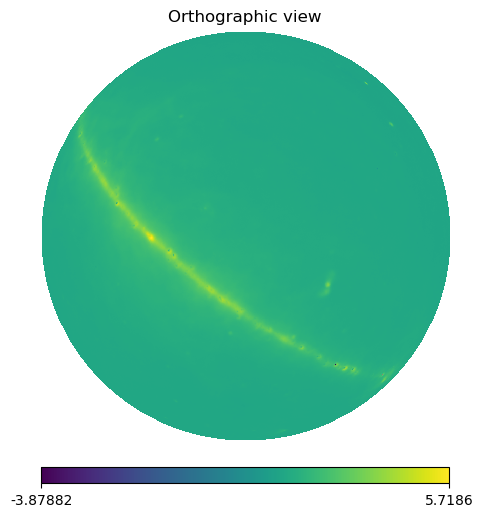

In [8]:
ov.generate(1400)
d = ov.view(logged=True)

And we can view galactic Mollweide projection too, with below-horizon data blanked out:

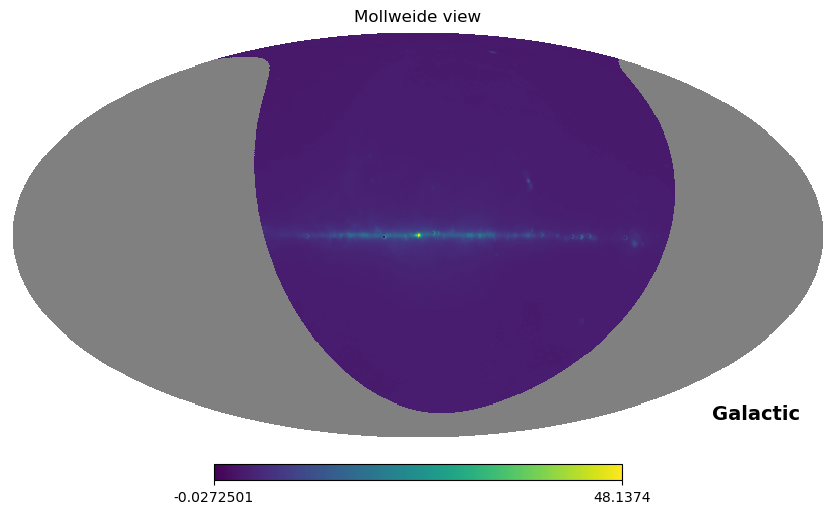

In [9]:
d = ov.view_observed_gsm()

## McKay et al. (2026) sky model

The `McKaySkyModel` is a version of GSM16 across 60-350 MHz, with a scale and offset applied to match absolute sky temperature measurements made in [McKay et al. (2026)](https://arxiv.org/abs/2509.11846).

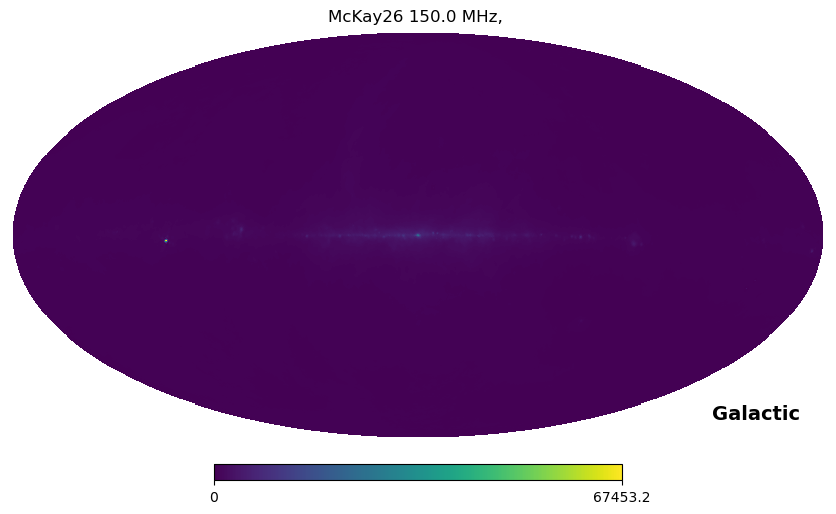

In [44]:
from pygdsm import McKaySkyModel

mkm = McKaySkyModel()
mkm_map = mkm.generate(150)
mkm.view(logged=False)

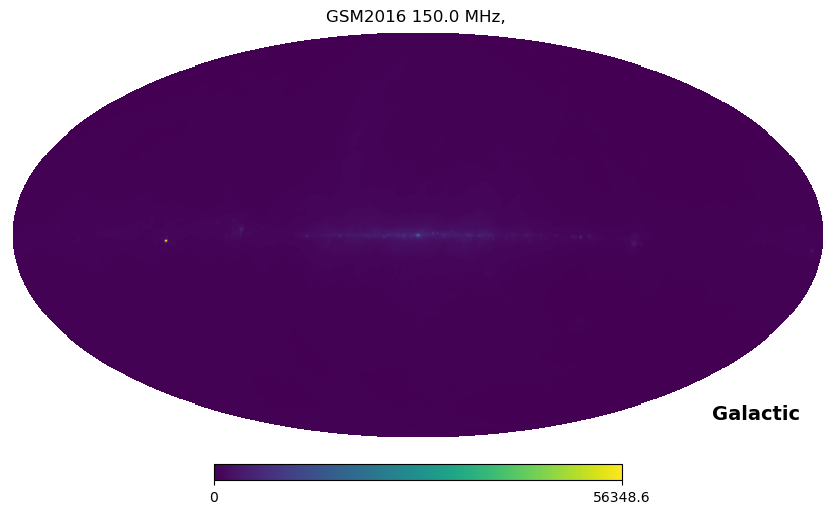

In [30]:
gsm16_map = gsm_2016.generate(150)
gsm_2016.view()


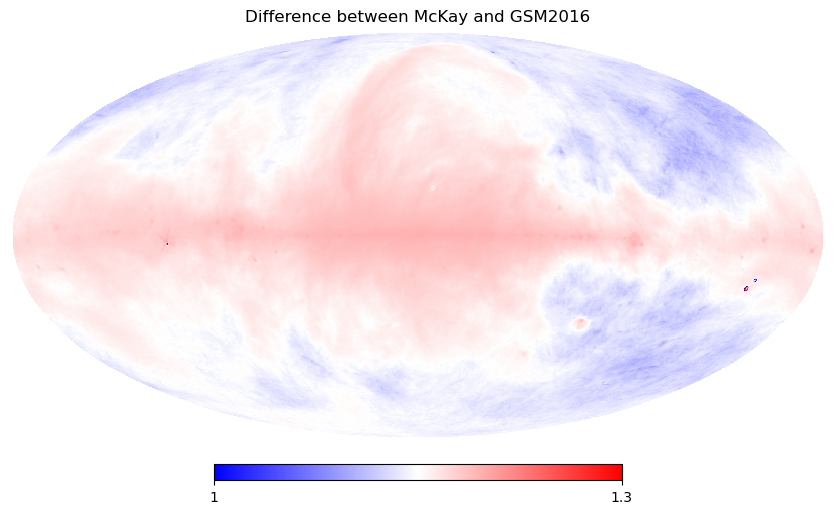

In [ ]:
hp.mollview(mkm_map / gsm16_map, title='Difference between McKay and GSM2016',
cmap='bwr', min=1, max=1.3)